In [49]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
# Some ploting setup
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('xtick', labelsize=12) 
plt.rc('ytick', labelsize=12)
fonttitle=18
fontlabel=12
savefig=True

In [50]:
import pandas as pd
filex = '../analytical_examples/homoflat/Ux_file_an'
filez = '../analytical_examples/homoflat/Uz_file_an'
filesource = '../analytical_examples/homoflat/source'
uz = pd.read_csv(filez, header=None, sep=r"\s+").to_numpy().ravel()
vz_analytic=-uz[~np.isnan(uz)].reshape(-1, 192)
time_analytic = vz_analytic[:, 0]*-1
vz_analytic = vz_analytic[:,1:]
ux = pd.read_csv(filex, header=None, sep=r"\s+").to_numpy().ravel()
vx_analytic=ux[~np.isnan(ux)].reshape(-1, 192)
vx_analytic = vx_analytic[:,1:]
source = pd.read_csv(filesource, header=None, sep=r"\s+").to_numpy().ravel().reshape(-1, 2)
source_analytic = source[:,1]

In [51]:
# Rotate componets
theta = -45.0  # degrees
theta_rad = np.deg2rad(theta)
vx_rotated = vx_analytic * np.cos(theta_rad) + vz_analytic * np.sin(theta_rad)
vz_rotated = -vx_analytic * np.sin(theta_rad) + vz_analytic * np.cos(theta_rad)
vx_analytic = vx_rotated
vz_analytic = vz_rotated

In [52]:
#normalized trace by trace
vx_analytic= vx_analytic / np.max(np.abs(vx_analytic))
vz_analytic = vz_analytic / np.max(np.abs(vz_analytic))

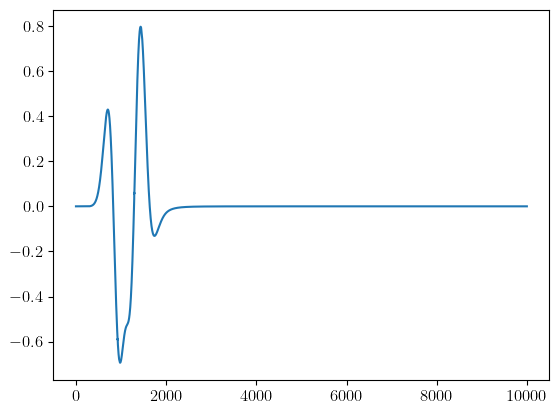

In [53]:
plt.plot(vz_analytic[:, 1])

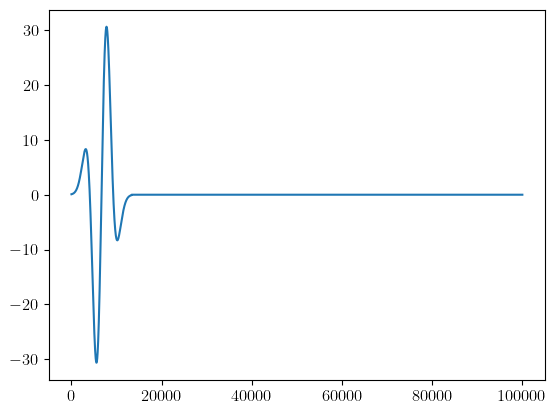

In [54]:
plt.plot(source_analytic)

In [55]:
time_analytic[0]

np.float64(0.00015)

In [56]:
with np.load('../devito_examples/homotilted/data_devito_homotilted.npz') as data:
    vx_devito = data['vx']
    vz_devito = data['vz']
    # vx_devito = data['v_xi']
    # vz_devito = data['v_eta']
    dt_devito = data['dt']

In [57]:
with np.load('../specfem2d_examples/homotilted/data_specfem_homotilted.npz') as data:
    vx_specfem = data['vx']
    vz_specfem = data['vz']
    time_specfem = data['time']

In [58]:
time_devito = np.arange(vx_devito.shape[0]) * dt_devito * 1e-3  # Convert ms to s
from scipy.interpolate import interp1d
interp_vx = interp1d(time_devito, vx_devito, axis=0, kind='cubic', bounds_error=False, fill_value=0.0)
interp_vz = interp1d(time_devito, vz_devito, axis=0, kind='cubic', bounds_error=False, fill_value=0.0)
vx_devito_interp = interp_vx(time_analytic) 
vz_devito_interp = interp_vz(time_analytic) 

# Compute time shift in trace at 50m
from scipy.signal import correlate, correlation_lags
trace = 1
corrz = correlate(vz_devito_interp[:, trace], vz_analytic[:, trace], mode='full')
corrx = correlate(vx_devito_interp[:, trace], vx_analytic[:, trace], mode='full')
lagsx = correlation_lags(len(vx_devito_interp[:, trace]), len(vx_analytic[:, trace]), mode='full')  # misma longitud que corr
dtx = time_analytic[1] - time_analytic[0]
time_shiftx = lagsx[np.argmax(corrx)] * dtx
lagsz = correlation_lags(len(vz_devito_interp[:, trace]), len(vz_analytic[:, trace]), mode='full')  # misma longitud que corr
dtz = time_analytic[1] - time_analytic[0]
time_shiftz = lagsz[np.argmax(corrz)] * dtz
time_shift = (time_shiftx + time_shiftz) / 2.0
print(f'Time shift between Devito and Analytic at trace {trace}: {time_shift:.4f} s')
# Apply time shift
time_analytic_shifted = time_analytic + time_shift
vx_devito_interp = interp_vx(time_analytic_shifted) 
vz_devito_interp = interp_vz(time_analytic_shifted)

# Trace by trace amplitude correction with dot product (trace by trace)
amplitude_correction_x = np.sum(vx_analytic * vx_devito_interp, axis=0) / np.sum(vx_devito_interp * vx_devito_interp, axis=0)
amplitude_correction_z = np.sum(vz_analytic * vz_devito_interp, axis=0) / np.sum(vz_devito_interp * vz_devito_interp, axis=0)
vx_devito_interp = vx_devito_interp * amplitude_correction_x
vz_devito_interp = vz_devito_interp * amplitude_correction_z

Time shift between Devito and Analytic at trace 1: 0.0012 s


In [59]:
time_shift = 0.1 # seconds
interp_vx_spec = interp1d(time_specfem+time_shift, vx_specfem, axis=0, kind='cubic', bounds_error=False, fill_value=0.0)
interp_vz_spec = interp1d(time_specfem+time_shift, vz_specfem, axis=0, kind='cubic', bounds_error=False, fill_value=0.0)
vx_specfem_interp = interp_vx_spec(time_analytic) 
vz_specfem_interp = interp_vz_spec(time_analytic) 
# Trace by trace amplitude correction with dot product (trace by trace)
amplitude_correction_x = np.sum(vx_analytic * vx_specfem_interp, axis=0) / np.sum(vx_specfem_interp * vx_specfem_interp, axis=0)
amplitude_correction_z = np.sum(vz_analytic * vz_specfem_interp, axis=0) / np.sum(vz_specfem_interp * vz_specfem_interp, axis=0)
vx_specfem_interp = vx_specfem_interp * amplitude_correction_x
vz_specfem_interp = vz_specfem_interp * amplitude_correction_z

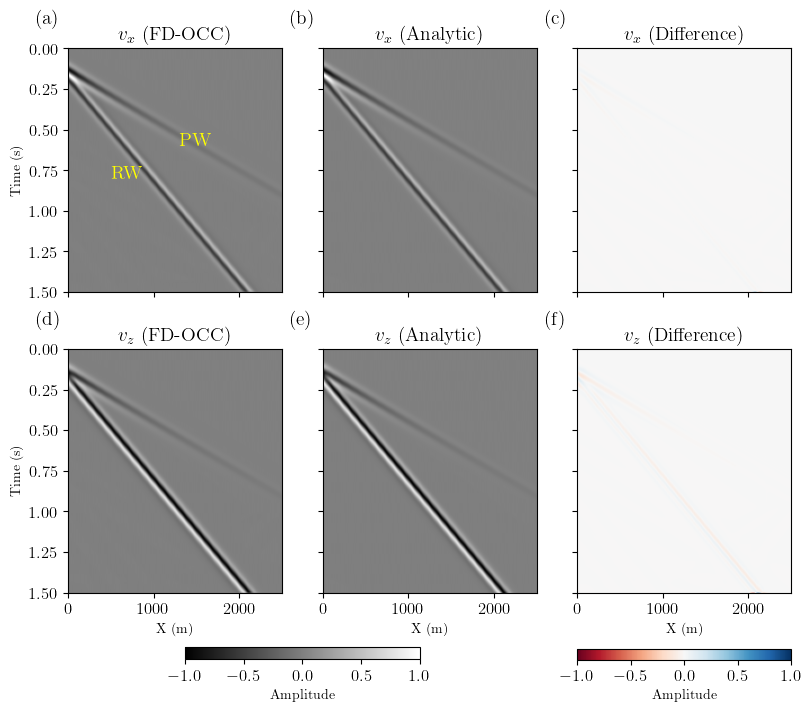

In [60]:
pcx=1.0
pcz=1.0
xmin=0
xmax=2500
cmap = 'gray'
cmapdif = 'RdBu'
extent = [xmin, xmax, time_analytic[-1], 0.0]
fig1, ax = plt.subplots(2, 3, layout='constrained', sharey=True, sharex=True, figsize=(8,7))

# VX
ax[0,0].set_title('$v_x$ (FD-OCC)', fontsize=14)
imx1=ax[0,0].imshow(vx_devito_interp, cmap=cmap, vmin=-pcx, vmax=pcx, origin='upper', aspect='auto',
           extent=extent)
ax[0,0].set_ylabel('Time (s)')
ax[0,1].set_title('$v_x$ (Analytic)', fontsize=14)
imx2=ax[0,1].imshow(vx_analytic, cmap=cmap, vmin=-pcx, vmax=pcx, origin='upper', aspect='auto',
           extent=extent)
ax[0,2].set_title('$v_x$ (Difference)', fontsize=14)
imx3 = ax[0,2].imshow(vx_devito_interp - vx_analytic, cmap=cmapdif, vmin=-pcx, vmax=pcx, origin='upper', aspect='auto',
           extent=extent)
# VZ
ax[1,0].set_title('$v_z$ (FD-OCC)', fontsize=14)
imv1=ax[1,0].imshow(vz_devito_interp, cmap=cmap, vmin=-pcz, vmax=pcz, origin='upper', aspect='auto',
           extent=extent)
ax[1,0].set_ylabel('Time (s)')
ax[1,0].set_xlabel('X (m)')
ax[1,1].set_title('$v_z$ (Analytic)', fontsize=14)
imv2=ax[1,1].imshow(vz_analytic, cmap=cmap, vmin=-pcz, vmax=pcz, origin='upper', aspect='auto',
           extent=extent)
ax[1,1].set_xlabel('X (m)')
fig1.colorbar(imv2, ax=ax[1,:2], orientation='horizontal', pad=0.04, shrink=0.5, label='Amplitude')
ax[1,2].set_title('$v_z$ (Difference)', fontsize=14)
imv3 = ax[1,2].imshow(vz_devito_interp - vz_analytic, cmap=cmapdif, vmin=-pcz, vmax=pcz, origin='upper', aspect='auto',
           extent=extent)
fig1.colorbar(imv3, ax=ax[:,2], orientation='horizontal', pad=0.02, label='Amplitude')
ax[1,2].set_xlabel('X (m)')

axi = ax[0,0]
axi.text(1300, 0.6, 'PW', fontsize=14, color='yellow')
axi.text(500, 0.8, 'RW', fontsize=14, color='yellow')


ax[0,0].text(-0.15, 1.1, '(a)', fontsize=14, transform=ax[0,0].transAxes)
ax[0,1].text(-0.15, 1.1, '(b)', fontsize=14, transform=ax[0,1].transAxes)
ax[0,2].text(-0.15, 1.1, '(c)', fontsize=14, transform=ax[0,2].transAxes)
ax[1,0].text(-0.15, 1.1, '(d)', fontsize=14, transform=ax[1,0].transAxes)
ax[1,1].text(-0.15, 1.1, '(e)', fontsize=14, transform=ax[1,1].transAxes)
ax[1,2].text(-0.15, 1.1, '(f)', fontsize=14, transform=ax[1,2].transAxes)
if savefig:
    fig1.savefig('homotilted_shotgather_comparison.pdf', bbox_inches='tight', transparent=True)

Text(-0.15, 1.1, '(f)')

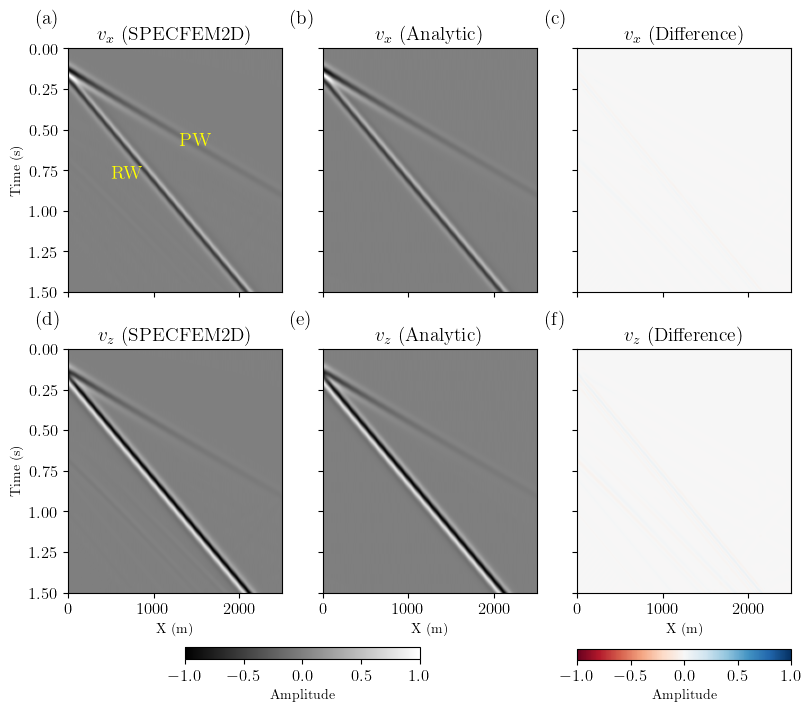

In [61]:
pcx=1.0
pcz=1.0
xmin=0
xmax=2500
cmap = 'gray'
cmapdif = 'RdBu'
extent = [xmin, xmax, time_analytic[-1], 0.0]
fig1, ax = plt.subplots(2, 3, layout='constrained', sharey=True, sharex=True, figsize=(8,7))

# VX
ax[0,0].set_title('$v_x$ (SPECFEM2D)', fontsize=14)
imx1=ax[0,0].imshow(vx_specfem_interp, cmap=cmap, vmin=-pcx, vmax=pcx, origin='upper', aspect='auto',
           extent=extent)
ax[0,0].set_ylabel('Time (s)')
ax[0,1].set_title('$v_x$ (Analytic)', fontsize=14)
imx2=ax[0,1].imshow(vx_analytic, cmap=cmap, vmin=-pcx, vmax=pcx, origin='upper', aspect='auto',
           extent=extent)
ax[0,2].set_title('$v_x$ (Difference)', fontsize=14)
imx3 = ax[0,2].imshow(vx_specfem_interp - vx_analytic, cmap=cmapdif, vmin=-pcx, vmax=pcx, origin='upper', aspect='auto',
           extent=extent)
# VZ
ax[1,0].set_title('$v_z$ (SPECFEM2D)', fontsize=14)
imv1=ax[1,0].imshow(vz_specfem_interp, cmap=cmap, vmin=-pcz, vmax=pcz, origin='upper', aspect='auto',
           extent=extent)
ax[1,0].set_ylabel('Time (s)')
ax[1,0].set_xlabel('X (m)')
ax[1,1].set_title('$v_z$ (Analytic)', fontsize=14)
imv2=ax[1,1].imshow(vz_analytic, cmap=cmap, vmin=-pcz, vmax=pcz, origin='upper', aspect='auto',
           extent=extent)
ax[1,1].set_xlabel('X (m)')
fig1.colorbar(imv2, ax=ax[1,:2], orientation='horizontal', pad=0.04, shrink=0.5, label='Amplitude')
ax[1,2].set_title('$v_z$ (Difference)', fontsize=14)
imv3 = ax[1,2].imshow(vz_specfem_interp - vz_analytic, cmap=cmapdif, vmin=-pcz, vmax=pcz, origin='upper', aspect='auto',
           extent=extent)
fig1.colorbar(imv3, ax=ax[:,2], orientation='horizontal', pad=0.02, label='Amplitude')
ax[1,2].set_xlabel('X (m)')

axi = ax[0,0]
axi.text(1300, 0.6, 'PW', fontsize=14, color='yellow')
axi.text(500, 0.8, 'RW', fontsize=14, color='yellow')


ax[0,0].text(-0.15, 1.1, '(a)', fontsize=14, transform=ax[0,0].transAxes)
ax[0,1].text(-0.15, 1.1, '(b)', fontsize=14, transform=ax[0,1].transAxes)
ax[0,2].text(-0.15, 1.1, '(c)', fontsize=14, transform=ax[0,2].transAxes)
ax[1,0].text(-0.15, 1.1, '(d)', fontsize=14, transform=ax[1,0].transAxes)
ax[1,1].text(-0.15, 1.1, '(e)', fontsize=14, transform=ax[1,1].transAxes)
ax[1,2].text(-0.15, 1.1, '(f)', fontsize=14, transform=ax[1,2].transAxes)


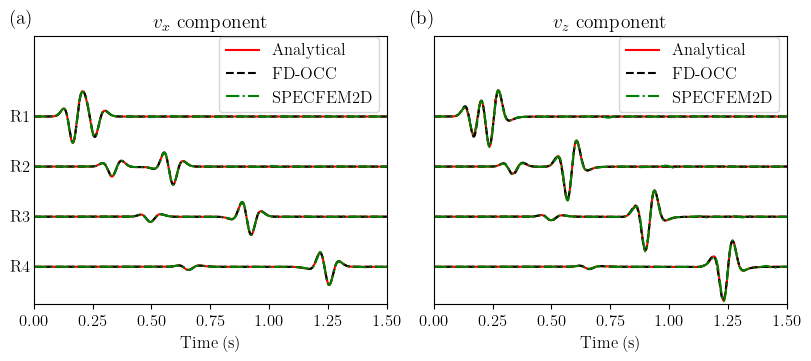

In [62]:
fig, ax = plt.subplots(1, 2, layout='constrained', sharey=True, figsize=(8, 3.5))
bias=0.0
traces = [8,48,88,128]
for trace in traces:

    bias -=  2  # for better visualization
    scale = 1.4
    ax[0].plot(time_analytic, vx_analytic[:, trace]*scale + bias, label='Analytical', color='red')
    ax[0].plot(time_analytic, vx_devito_interp[:, trace]*scale + bias, label='Devito', color='black', linestyle='--')
    ax[0].plot(time_analytic, vx_specfem_interp[:, trace]*scale + bias, label='Specfem', color='green', linestyle='-.')
    ax[1].plot(time_analytic, vz_analytic[:, trace]*scale + bias, label='Analytical', color='red')
    ax[1].plot(time_analytic, vz_devito_interp[:, trace]*scale + bias, label='Devito', color='black', linestyle='--')
    ax[1].plot(time_analytic, vz_specfem_interp[:, trace]*scale + bias, label='Specfem', color='green', linestyle='-.')
ax[0].set_title('$v_x$ component', fontsize=14)
ax[1].set_title('$v_z$ component', fontsize=14)
ax[0].set_xlim(0, 1.5)
ax[0].set_ylim(-9.5, 1.2)
ax[1].set_xlim(0, 1.5)
ax[0].legend(['Analytical', 'FD-OCC', 'SPECFEM2D'], fontsize=12, loc='upper right', bbox_to_anchor=(1.0, 1.028))
ax[1].legend(['Analytical', 'FD-OCC', 'SPECFEM2D'], fontsize=12, loc='upper right', bbox_to_anchor=(1.0, 1.028))
ax[0].set_xlabel('Time (s)', fontsize=12)
ax[1].set_xlabel('Time (s)', fontsize=12)
ax[0].text(-0.1, -2.2, 'R1', fontsize=12)
ax[0].text(-0.1, -2.2-2, 'R2', fontsize=12)
ax[0].text(-0.1, -2.2-2*2, 'R3', fontsize=12)
ax[0].text(-0.1, -2.2-2*3, 'R4', fontsize=12)
ax[0].text(-0.1, 1.7, '(a)', fontsize=14)
ax[1].text(-0.1, 1.7, '(b)', fontsize=14)
ax[0].set_yticks([])
if savefig:
    fig.savefig('homotilted_traces_comparison.pdf', bbox_inches='tight', transparent=True)

In [63]:
# L2 error in trace 100
for trace in traces:

    vx_devito_trace = vx_devito_interp[:, trace] 
    vz_devito_trace = vz_devito_interp[:, trace]
    vx_specfem_trace = vx_specfem_interp[:, trace] 
    vz_specfem_trace = vz_specfem_interp[:, trace] 
    # L2 relative error
    error_vx_dev = np.linalg.norm(vx_devito_trace - vx_analytic[:, trace]) / np.linalg.norm(vx_analytic[:, trace])
    error_vz_dev = np.linalg.norm(vz_devito_trace - vz_analytic[:, trace]) / np.linalg.norm(vz_analytic[:, trace])     
    error_vx_spec = np.linalg.norm(vx_specfem_trace - vx_analytic[:, trace]) / np.linalg.norm(vx_analytic[:, trace]) 
    error_vz_spec = np.linalg.norm(vz_specfem_trace - vz_analytic[:, trace]) / np.linalg.norm(vz_analytic[:, trace])     
    # L2 (squared) relative error
    error_vx_dev_2 = np.linalg.norm(vx_devito_trace - vx_analytic[:, trace])**2 / np.linalg.norm(vx_analytic[:, trace])**2
    error_vz_dev_2 = np.linalg.norm(vz_devito_trace - vz_analytic[:, trace])**2 / np.linalg.norm(vz_analytic[:, trace])**2     
    error_vx_spec_2 = np.linalg.norm(vx_specfem_trace - vx_analytic[:, trace])**2 / np.linalg.norm(vx_analytic[:, trace])**2 
    error_vz_spec_2 = np.linalg.norm(vz_specfem_trace - vz_analytic[:, trace])**2 / np.linalg.norm(vz_analytic[:, trace])**2 
    # Correlation measure
    corr_vx_dev = np.inner(vx_analytic[:, trace], vx_devito_trace) / (np.linalg.norm(vx_analytic[:, trace]) * np.linalg.norm(vx_devito_trace))
    corr_vz_dev = np.inner(vz_analytic[:, trace], vz_devito_trace) / (np.linalg.norm(vz_analytic[:, trace]) * np.linalg.norm(vz_devito_trace))
    corr_vx_spec = np.inner(vx_analytic[:, trace], vx_specfem_trace) / (np.linalg.norm(vx_analytic[:, trace]) * np.linalg.norm(vx_specfem_trace))
    corr_vz_spec = np.inner(vz_analytic[:, trace], vz_specfem_trace) / (np.linalg.norm(vz_analytic[:, trace]) * np.linalg.norm(vz_specfem_trace))
    print(f'Correlation at trace {trace}:')  
    print(f'Correlation vx (specfem): {corr_vx_spec:.2%} (devito): {corr_vx_dev:.2%}')
    print(f'Correlation vz (specfem): {corr_vz_spec:.2%} (devito): {corr_vz_dev:.2%}')  

    print(f'L2 Relative Error at trace {trace}:')  
    print(f'Relative L2 (squared) error vx (specfem): {error_vx_spec_2:.2%} (devito): {error_vx_dev_2:.2%}')
    print(f'Relative L2 (squared) error vz (specfem): {error_vz_spec_2:.2%} (devito): {error_vz_dev_2:.2%}')

Correlation at trace 8:
Correlation vx (specfem): 99.94% (devito): 99.90%
Correlation vz (specfem): 99.86% (devito): 99.66%
L2 Relative Error at trace 8:
Relative L2 (squared) error vx (specfem): 0.13% (devito): 0.19%
Relative L2 (squared) error vz (specfem): 0.28% (devito): 0.67%
Correlation at trace 48:
Correlation vx (specfem): 99.84% (devito): 99.95%
Correlation vz (specfem): 99.82% (devito): 99.82%
L2 Relative Error at trace 48:
Relative L2 (squared) error vx (specfem): 0.32% (devito): 0.09%
Relative L2 (squared) error vz (specfem): 0.36% (devito): 0.35%
Correlation at trace 88:
Correlation vx (specfem): 99.82% (devito): 99.98%
Correlation vz (specfem): 99.85% (devito): 99.83%
L2 Relative Error at trace 88:
Relative L2 (squared) error vx (specfem): 0.36% (devito): 0.05%
Relative L2 (squared) error vz (specfem): 0.31% (devito): 0.33%
Correlation at trace 128:
Correlation vx (specfem): 99.85% (devito): 99.96%
Correlation vz (specfem): 99.85% (devito): 99.76%
L2 Relative Error at tra

In [64]:
norm_devito_vx = np.linalg.norm(vx_devito_interp)
norm_specfem_vx = np.linalg.norm(vx_specfem_interp)
norm_analytic_vx = np.linalg.norm(vx_analytic)
error_dev_vx = np.linalg.norm(vx_devito_interp - vx_analytic)**2 / norm_analytic_vx**2
error_spec_vx = np.linalg.norm(vx_specfem_interp - vx_analytic)**2 / norm_analytic_vx**2
norm_devito_vz = np.linalg.norm(vz_devito_interp)
norm_specfem_vz = np.linalg.norm(vz_specfem_interp)
norm_analytic_vz = np.linalg.norm(vz_analytic)
error_dev_vz = np.linalg.norm(vz_devito_interp - vz_analytic)**2 / norm_analytic_vz**2
error_spec_vz = np.linalg.norm(vz_specfem_interp - vz_analytic)**2 / norm_analytic_vz**2

print(f'Relative L2 error vx (Devito vs Analytic): {error_dev_vx:.2%}')
print(f'Relative L2 error vz (Devito vs Analytic): {error_dev_vz:.2%}')
print(f'Relative L2 error vx (Specfem vs Analytic): {error_spec_vx:.2%}')
print(f'Relative L2 error vz (Specfem vs Analytic): {error_spec_vz:.2%}')
# Correlation all the traces (entire shot gather)
correlation_dev_x = np.sum(vx_analytic * vx_devito_interp) / (norm_analytic_vx * norm_devito_vx)
correlation_dev_z = np.sum(vz_analytic * vz_devito_interp) / (norm_analytic_vz * norm_devito_vz)
correlation_spec_x = np.sum(vx_analytic * vx_specfem_interp) / (norm_analytic_vx * norm_specfem_vx)
correlation_spec_z = np.sum(vz_analytic * vz_specfem_interp) / (norm_analytic_vz * norm_specfem_vz)

print(f'Correlation vx (Devito vs Analytic): {correlation_dev_x:.2%}')
print(f'Correlation vz (Devito vs Analytic): {correlation_dev_z:.2%}')
print(f'Correlation vx (Specfem vs Analytic): {correlation_spec_x:.2%}')
print(f'Correlation vz (Specfem vs Analytic): {correlation_spec_z:.2%}')

Relative L2 error vx (Devito vs Analytic): 0.19%
Relative L2 error vz (Devito vs Analytic): 0.58%
Relative L2 error vx (Specfem vs Analytic): 0.25%
Relative L2 error vz (Specfem vs Analytic): 0.32%
Correlation vx (Devito vs Analytic): 99.90%
Correlation vz (Devito vs Analytic): 99.71%
Correlation vx (Specfem vs Analytic): 99.87%
Correlation vz (Specfem vs Analytic): 99.84%
